# Evaluation

In [14]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

results_filepath = "results/experiments.jsonl"

with open(results_filepath) as f:
    records = [json.loads(line) for line in f if line.strip()]

rows = []
for record in records:
    row = {"id": record["id"]}
    row.update(record["experiment"])
    row.update(record["evaluation"])
    rows.append(row)

data = pd.DataFrame(rows)

hyperparameter_columns = ["algorithm", "policy", "timesteps", "learning_rate", "gamma"]
metric_columns = [
    "mean_episode_reward",
    "std_episode_reward",
    "mean_steps_per_episode",
    "score",
    "train_time",
    "test_time",
]

aggregated = (
    data.groupby(hyperparameter_columns, as_index=False)[metric_columns]
    .mean()
)

In [15]:
best_indices = aggregated.groupby("algorithm")["score"].idxmax()
best = aggregated.loc[best_indices].sort_values("score", ascending=False).reset_index(drop=True)
best

,algorithm,policy,timesteps,learning_rate,gamma,mean_episode_reward,std_episode_reward,mean_steps_per_episode,score,train_time,test_time
0,PPO,CnnPolicy,1000000,0.00005,0.95,14.033333,1.546978,228.300000,14.033333,1420.255497,5.230104
1,DQN,CnnPolicy,1000000,0.00030,0.99,12.633333,3.791242,215.433333,12.633333,877.310653,4.975842
2,A2C,CnnPolicy,1000000,0.00030,0.99,5.800000,0.891564,141.333333,5.800000,938.620721,4.314902


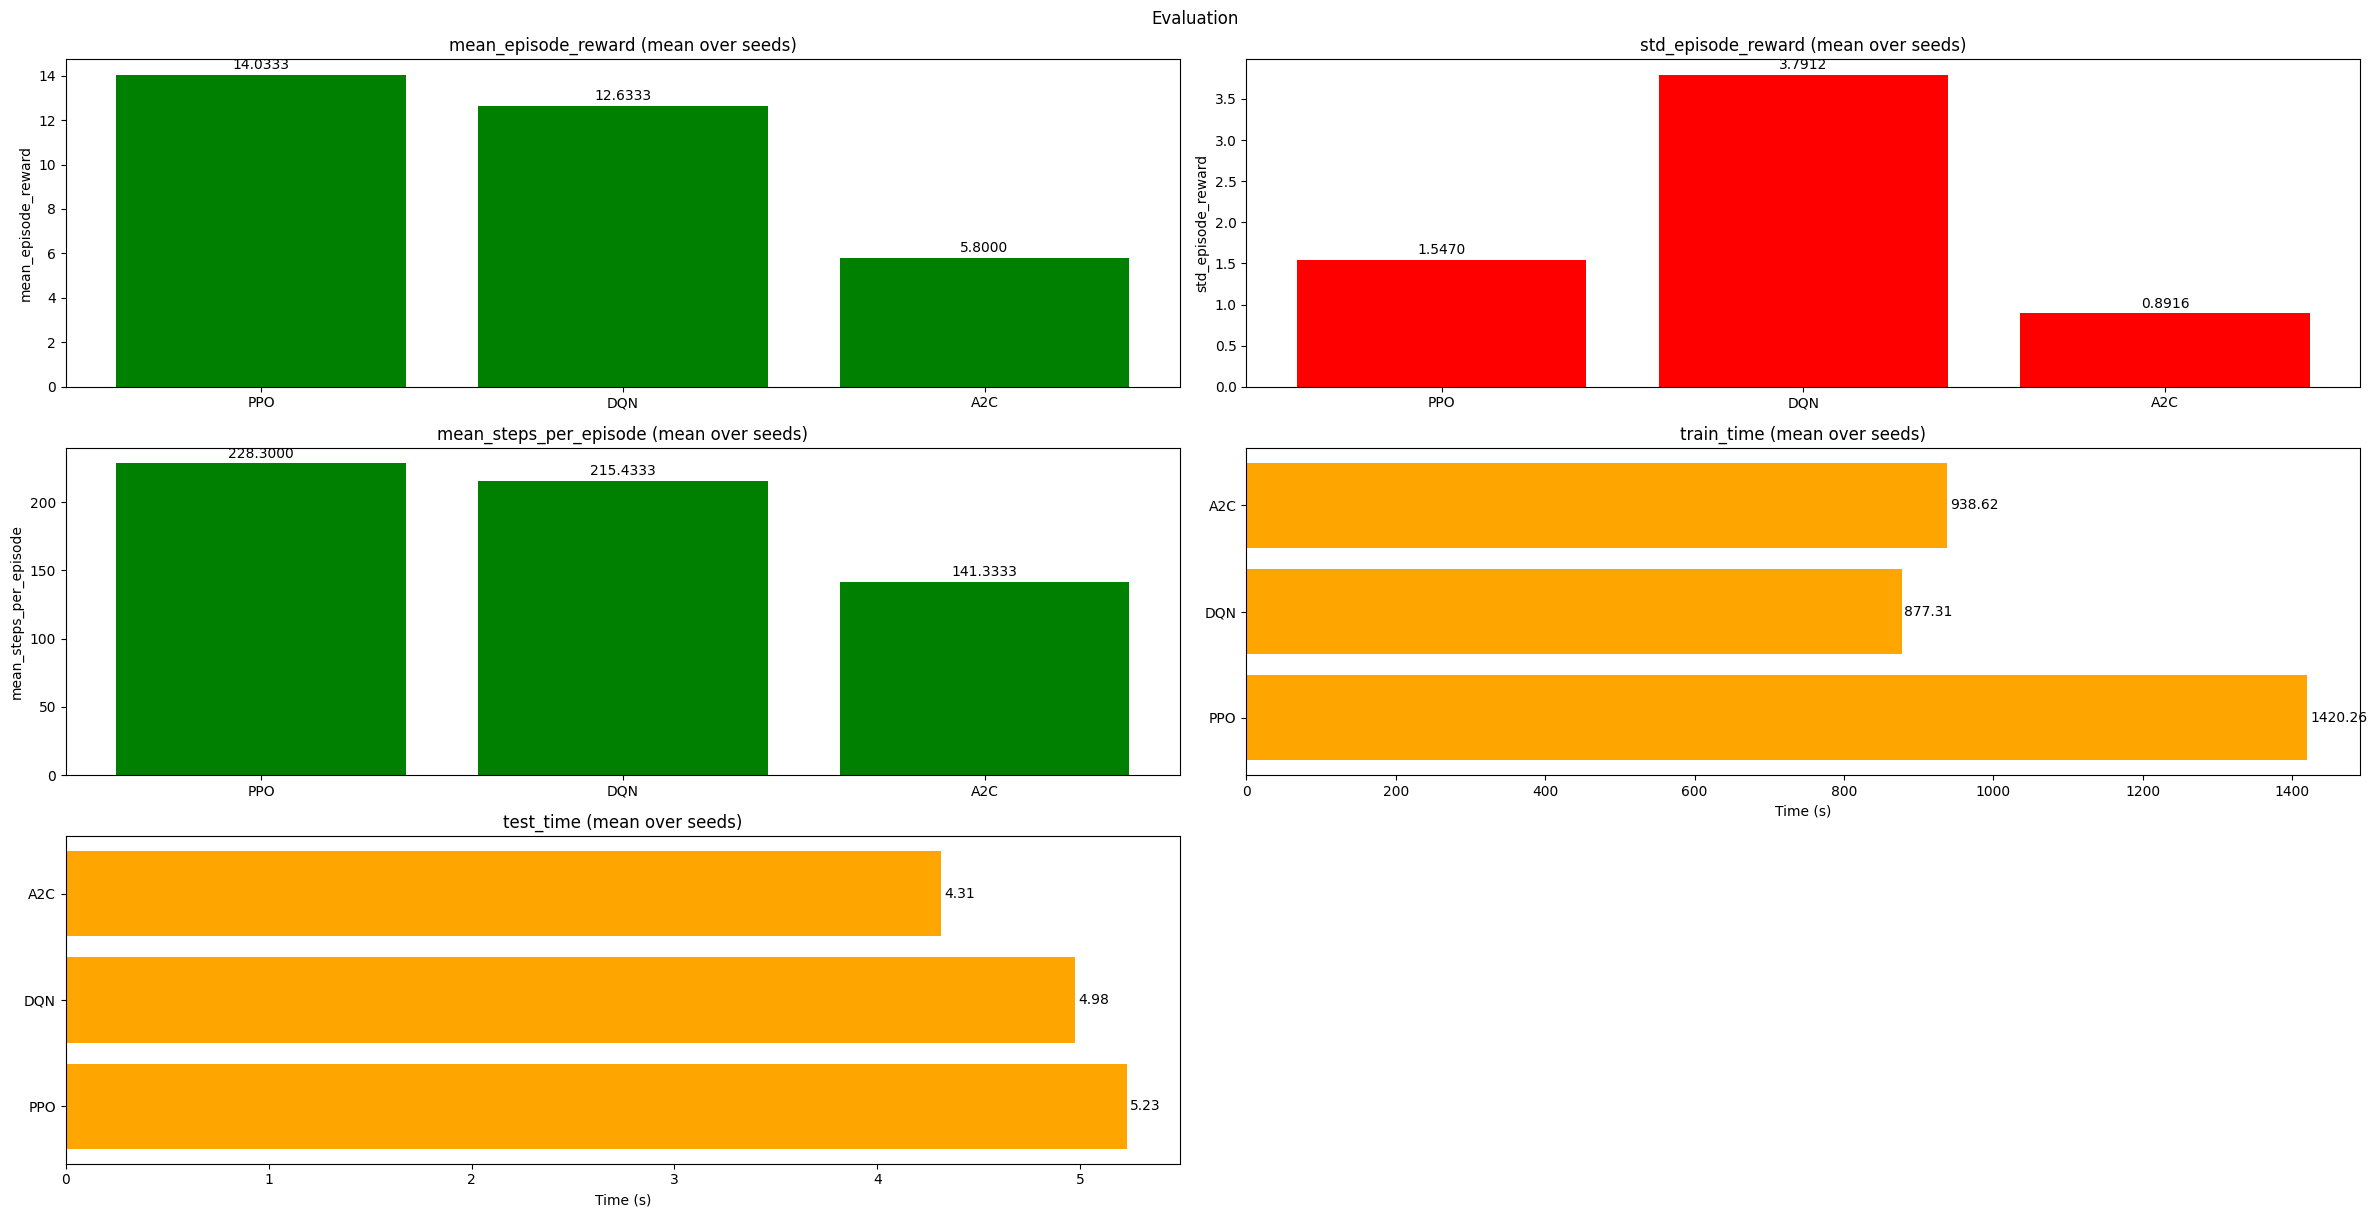

In [16]:
metrics_columns = [
    "mean_episode_reward",
    "std_episode_reward",
    "mean_steps_per_episode",
    "train_time",
    "test_time",
]

higher_better = ["mean_episode_reward", "mean_steps_per_episode"]
lower_better = ["std_episode_reward"]
time_metrics = ["train_time", "test_time"]

total_metrics = len(metrics_columns)
columns = 2
total_rows = math.ceil(total_metrics / columns)
figures, axes = plt.subplots(total_rows, columns, figsize=(12 * columns, 4 * total_rows))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_columns):
    colour = "green"
    if metric in lower_better:
        colour = "red"
    if metric in time_metrics:
        colour = "orange"

    for _, row in best.iterrows():
        label = row["algorithm"]
        value = row[metric]

        if metric in time_metrics:
            bars = ax.barh(label, value, color=colour)
            ax.set_xlabel("Time (s)")
            ax.bar_label(bars, fmt="%.2f", padding=2)
        else:
            bars = ax.bar(label, value, color=colour)
            ax.set_ylabel(metric)
            ax.bar_label(bars, fmt="%.4f", padding=2)

    ax.set_title(f"{metric} (mean over seeds)")

for ax in axes[total_metrics:]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Evaluation", y=1.01)
plt.show()

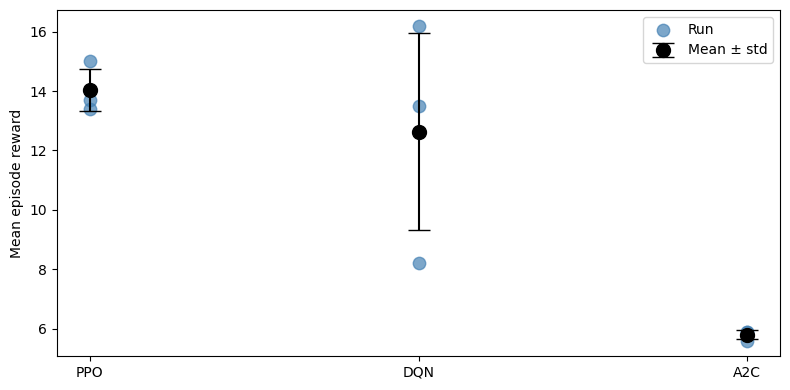

In [17]:
best_keys = best[["algorithm", "policy", "timesteps", "learning_rate", "gamma"]]
best_runs = data.merge(best_keys, on=list(best_keys.columns), how="inner")

fig, ax = plt.subplots(figsize=(8, 4))
algorithms = best["algorithm"].tolist()
positions = range(len(algorithms))

for index, algorithm in enumerate(algorithms):
    group = best_runs[best_runs["algorithm"] == algorithm]
    rewards = group["mean_episode_reward"].tolist()
    ax.scatter([index] * len(rewards), rewards, color="steelblue", alpha=0.7, s=80, label="Run" if index == 0 else None)
    ax.errorbar(
        index,
        group["mean_episode_reward"].mean(),
        yerr=group["mean_episode_reward"].std(ddof=0),
        fmt="o",
        color="black",
        capsize=8,
        markersize=10,
        label="Mean ± std" if index == 0 else None,
    )

ax.set_xticks(list(positions))
ax.set_xticklabels(algorithms)
ax.set_ylabel("Mean episode reward")
ax.legend()
plt.tight_layout()
plt.show()